# Three Views of the Phasor SSM

The Phasor SSM admits three equivalent computational views:

1. **Continuous**: solve the R&F ODE with a numerical integrator
2. **Discrete**: iterate the recurrence $U_c[n+1] = e^{k_c T} \cdot U_c[n] + H_c[n]$
3. **Convolutional**: precompute the kernel $K_c[n] = e^{k_c \cdot n \cdot T}$, compute $U = K * H$ via FFT

This notebook visualizes the impulse-response kernels and demonstrates
that all three views produce the same output.

In [1]:
using PhasorNetworks
using Lux, Random, Statistics
using Plots

## 1. Impulse-Response Kernels

The kernel $K_c[n] = e^{k_c \cdot n \cdot T}$ with $k_c = \lambda_c + i\omega_c$
is a decaying complex exponential. Its magnitude decays as $e^{\lambda_c n T}$
and its phase advances by $\omega_c T$ per step. Different $(\lambda, \omega)$
pairs produce different temporal receptive fields.

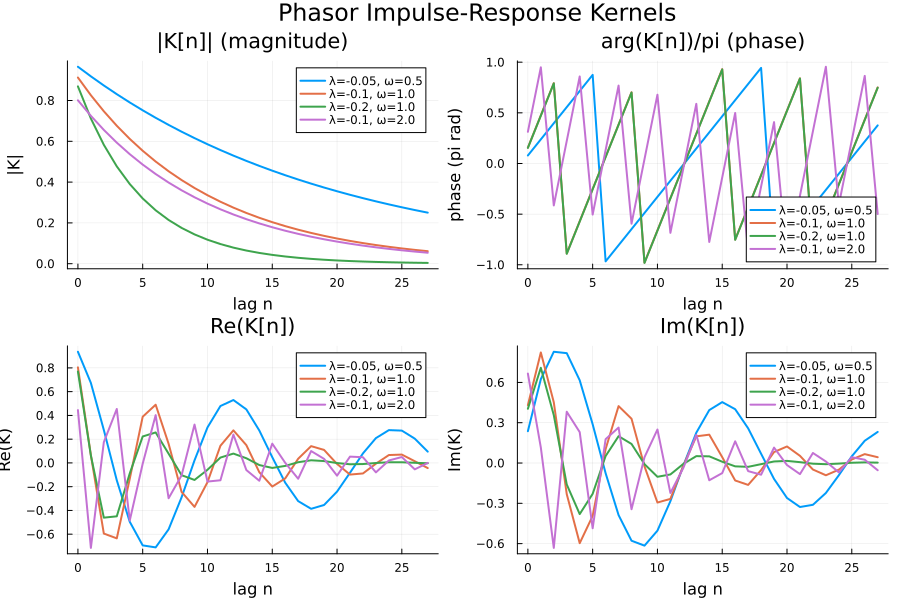

In [2]:
L = 28
ts = 0:L-1

# Four representative oscillators
lambda_viz = Float32[-0.05, -0.1, -0.2, -0.1]
omega_viz = Float32[0.5, 1.0, 1.0, 2.0]
K_viz = phasor_kernel(lambda_viz, omega_viz, 1f0, L)

labels = ["\u03bb=-0.05, \u03c9=0.5" "\u03bb=-0.1, \u03c9=1.0" "\u03bb=-0.2, \u03c9=1.0" "\u03bb=-0.1, \u03c9=2.0"]

p1 = plot(ts, abs.(K_viz)', title="|K[n]| (magnitude)",
          xlabel="lag n", ylabel="|K|", label=labels, lw=2)
p2 = plot(ts, angle.(K_viz)' ./ pi, title="arg(K[n])/pi (phase)",
          xlabel="lag n", ylabel="phase (pi rad)", label=labels, lw=2)
p3 = plot(ts, real.(K_viz)', title="Re(K[n])",
          xlabel="lag n", ylabel="Re(K)", label=labels, lw=2)
p4 = plot(ts, imag.(K_viz)', title="Im(K[n])",
          xlabel="lag n", ylabel="Im(K)", label=labels, lw=2)

fig = plot(p1, p2, p3, p4; layout=(2, 2), size=(900, 600),
     plot_title="Phasor Impulse-Response Kernels")

fig

## 2. Kernel Heatmap

A bank of oscillators with varied $(\lambda, \omega)$ forms a filter bank.
Each row is one channel's kernel magnitude across time lags.

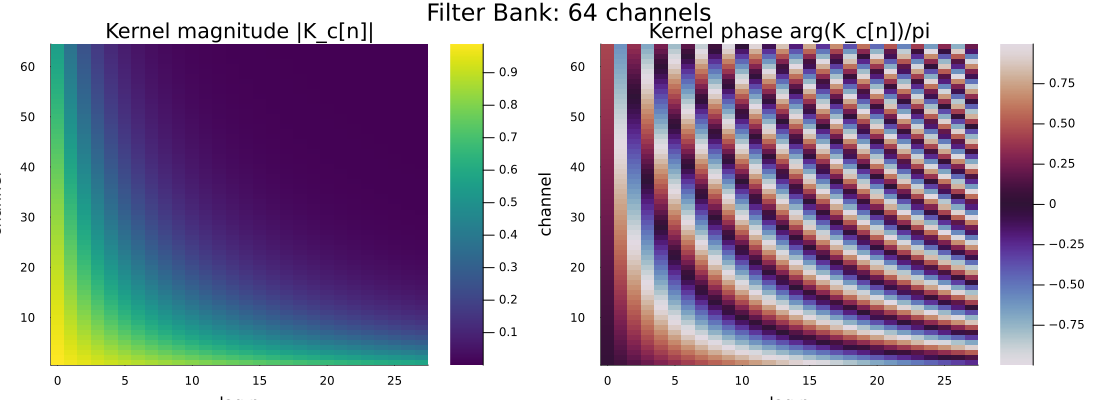

In [9]:
C = 64
L_heat = 28

# Spread lambda and omega across channels
lambda_bank = Float32.(collect(range(-0.02, -0.4; length=C)))
omega_bank = Float32.(collect(range(0.2, 3.0; length=C)))
K_bank = phasor_kernel(lambda_bank, omega_bank, 1f0, L_heat)

p_mag = heatmap(0:L_heat-1, 1:C, abs.(K_bank),
                xlabel="lag n", ylabel="channel",
                title="Kernel magnitude |K_c[n]|", color=:viridis,
                size=(700, 400))

p_phase = heatmap(0:L_heat-1, 1:C, angle.(K_bank) ./ pi,
                  xlabel="lag n", ylabel="channel",
                  title="Kernel phase arg(K_c[n])/pi", color=:twilight,
                  size=(700, 400))

fig = plot(p_mag, p_phase; layout=(1, 2), size=(1100, 400),
     plot_title="Filter Bank: $C channels")

In [10]:
png(fig, "../kernels.png")

"../kernels.png"

## 3. Toeplitz vs FFT Convolution

The causal convolution $U_c[n] = \sum_j K_c[n-j] \cdot H_c[j]$ can be computed
via lower-triangular Toeplitz matrix multiplication (exact, $O(L^2)$) or via
zero-padded FFT ($O(L \log L)$). Both should produce identical results.

Max absolute error (Toeplitz vs FFT): 1.0662403e-6


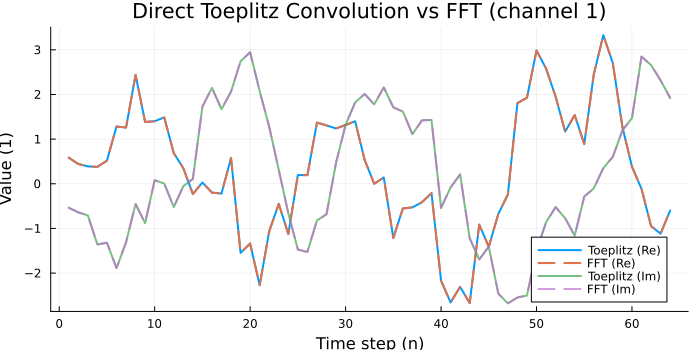

In [11]:
rng = Xoshiro(42)
C, L, B = 8, 64, 2

lambda = fill(-0.1f0, C)
omega = Float32.(collect(range(0.2f0, 2.5f0; length=C)))
K = phasor_kernel(lambda, omega, 1f0, L)
H = randn(rng, ComplexF32, C, L, B)

Z_toeplitz = PhasorNetworks._causal_conv_toeplitz(K, H)
Z_fft = causal_conv_fft(K, H)

max_error = maximum(abs.(Z_toeplitz .- Z_fft))
println("Max absolute error (Toeplitz vs FFT): $max_error")

# Plot one channel, one batch element
ch, b = 1, 1
p = plot(real.(Z_toeplitz[ch, :, b]), label="Toeplitz (Re)", lw=2)
plot!(p, real.(Z_fft[ch, :, b]), label="FFT (Re)", lw=2, ls=:dash)
plot!(p, imag.(Z_toeplitz[ch, :, b]), label="Toeplitz (Im)", lw=2, alpha=0.7)
plot!(p, imag.(Z_fft[ch, :, b]), label="FFT (Im)", lw=2, ls=:dash, alpha=0.7)
plot!(p, title="Direct Toeplitz Convolution vs FFT (channel $ch)",
      xlabel="Time step (n)", ylabel="Value (1)", size=(700, 350))

In [12]:
png(fig, "../conv_vs_fft.png")

"../conv_vs_fft.png"

## 4. Discrete Recurrence vs Convolution

The recurrence $U_c[n+1] = \bar{A}_c \cdot U_c[n] + H_c[n]$ and the convolution
$U = K * H$ are algebraically identical. We verify by computing both.

Max absolute error (recurrence vs convolution): 2.8531847
Max absolute error (recurrence vs Dirac convolution): 1.673182e-6


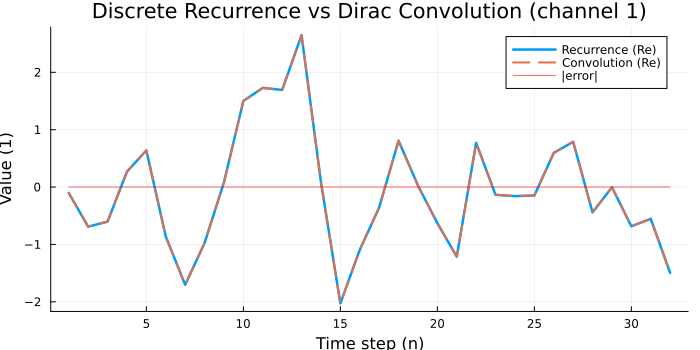

In [13]:
C, L, B = 4, 32, 1
lambda_r = Float32[-0.1, -0.15, -0.2, -0.05]
omega_r = Float32[1.0, 1.5, 0.8, 2.0]
k_vals = ComplexF32.(lambda_r .+ im .* omega_r)
A_bar = exp.(k_vals .* 1f0)  # per-channel transition

H_r = randn(rng, ComplexF32, C, L, B)

# --- Method 1: Step-by-step recurrence ---
Z_recurrent = zeros(ComplexF32, C, L, B)
for n in 1:L
    if n == 1
        Z_recurrent[:, n, :] .= H_r[:, n, :]
    else
        Z_recurrent[:, n, :] .= A_bar .* Z_recurrent[:, n-1, :] .+ H_r[:, n, :]
    end
end

# --- Method 2: Causal convolution ---
K_r = phasor_kernel(lambda_r, omega_r, 1f0, L)
Z_conv = causal_conv(K_r, H_r)

max_error = maximum(abs.(Z_recurrent .- Z_conv))
println("Max absolute error (recurrence vs convolution): $max_error")

# Note: the convolution kernel includes the B gain factor.
# For the Dirac kernel K[n] = A^n (no B), we need to adjust.
# The phasor_kernel function returns K[n] = A^n * B where B = (A-1)/k.
# To match the recurrence H -> A*U + H exactly, we convolve with
# a unit-gain kernel. Let's verify with the raw exponential:

# Dirac kernel (no ZOH gain)
ns = Float32.(0:L-1)
K_dirac = exp.(k_vals .* reshape(ns, 1, L))  # C x L

Z_dirac_conv = causal_conv(K_dirac, H_r)

# Recurrence with Dirac kernel: U[n+1] = A*U[n] + H[n] is the same
# as convolving with K[n] = A^n (the delta at n=0 gives K[0]=1, which
# means the n=0 input passes through directly)
max_error_dirac = maximum(abs.(Z_recurrent .- Z_dirac_conv))
println("Max absolute error (recurrence vs Dirac convolution): $max_error_dirac")

ch = 1
p = plot(real.(Z_recurrent[ch, :, 1]), label="Recurrence (Re)", lw=2.5)
plot!(p, real.(Z_dirac_conv[ch, :, 1]), label="Convolution (Re)",
      lw=2, ls=:dash)
plot!(p, abs.(Z_recurrent[ch, :, 1] .- Z_dirac_conv[ch, :, 1]),
      label="|error|", lw=1, color=:red, alpha=0.6)
plot!(p, title="Discrete Recurrence vs Dirac Convolution (channel $ch)",
      xlabel="Time step (n)", ylabel="Value (1)", size=(700, 350))

In [14]:
png(p, "../discrete_vs_dirac.png")

"../discrete_vs_dirac.png"

## 5. Dirac Convolution vs Spiking ODE

The Dirac discretization is the **exact** analytical solution for spike inputs.
The spiking ODE solves the same equation numerically:
`dz_c/dt = k_c * z_c + sum_j W[c,j] * I_j(t)`, where spikes arrive as current
impulses. Both should produce the same answer --- the Dirac formula is the
closed-form solution of this ODE for instantaneous impulse inputs.

The remaining gap between the two comes only from the ODE solver using a
finite-width spike kernel (not a true Dirac delta) and finite temporal steps.

In [19]:
rng = Xoshiro(42)
C_in, C_out = 4, 8
L, B = 8, 3

layer = PhasorDense(C_in => C_out, normalize_to_unit_circle;
                    init_mode=:uniform, use_bias=false,
                    return_type=SolutionType(:phase))
ps, st = Lux.setup(rng, layer)

lambda_c = -exp.(ps.log_neg_lambda)
omega_c = st.omega
k_c = ComplexF32.(lambda_c .+ im .* omega_c)

# Random phase input
phases_in = Phase.(2f0 .* rand(rng, Float32, C_in, L, B) .- 1f0)

# --- Path 1: Dirac convolution (exact analytical) ---
phases_dirac, _ = layer(phases_in, ps, st)

# --- Path 2: Spiking ODE (numerical, single-stage) ---
# dz_c/dt = k_c * z_c + W * I(t), sampled at period boundaries
spk_args = SpikingArgs(leakage=-0.2f0, t_period=1.0f0, t_window=0.005f0,
                       solver_args=Dict(:dt => 0.001f0,
                                        :adaptive => false,
                                        :save_start => true))

train = ssm_phases_to_train(phases_in, spk_args=spk_args)
tspan_spk = (0.0f0, Float32(L) * spk_args.t_period)
sc = SpikingCall(train, spk_args, tspan_spk)
phases_spiking, _ = layer(sc, ps, st)

c = cor(vec(Float32.(phases_dirac)), vec(Float32.(phases_spiking)))
println("Dirac vs Spiking ODE correlation: ", round(c; digits=4))
println("Shapes: dirac=$(size(phases_dirac)), spiking=$(size(phases_spiking))")

# --- Get raw ODE solution for dense visualization ---
layer_pot = PhasorDense(C_in => C_out, normalize_to_unit_circle;
                        init_mode=:uniform, use_bias=false,
                        return_type=SolutionType(:potential))
sol_ode, _ = layer_pot(sc, ps, st)

Dirac vs Spiking ODE correlation: 1.0
Shapes: dirac=(8, 8, 3), spiking=(8, 8, 3)


(SciMLBase.ODESolution{ComplexF32, 3, Vector{Matrix{ComplexF32}}, Nothing, Nothing, Vector{Float32}, Vector{Vector{Matrix{ComplexF32}}}, Nothing, SciMLBase.ODEProblem{Matrix{ComplexF32}, Tuple{Float32, Float32}, false, @NamedTuple{weight::Matrix{Float32}, log_neg_lambda::Vector{Float32}}, SciMLBase.ODEFunction{false, SciMLBase.AutoSpecialize, PhasorNetworks.var"#dzdt#dzdt##0"{PhasorDense, CurrentCall, @NamedTuple{omega::Vector{Float32}}, Bool, SpikingArgs}, LinearAlgebra.UniformScaling{Bool}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, typeof(SciMLBase.DEFAULT_OBSERVED), Nothing, Nothing, Nothing, Nothing}, Base.Pairs{Symbol, Union{}, Nothing, @NamedTuple{}}, SciMLBase.StandardODEProblem}, OrdinaryDiffEqLowOrderRK.Heun{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), Static.False}, OrdinaryDiffEqCore.InterpolationData{SciMLBase.ODEFunction{false, SciMLBase.AutoSpecialize, PhasorNetw

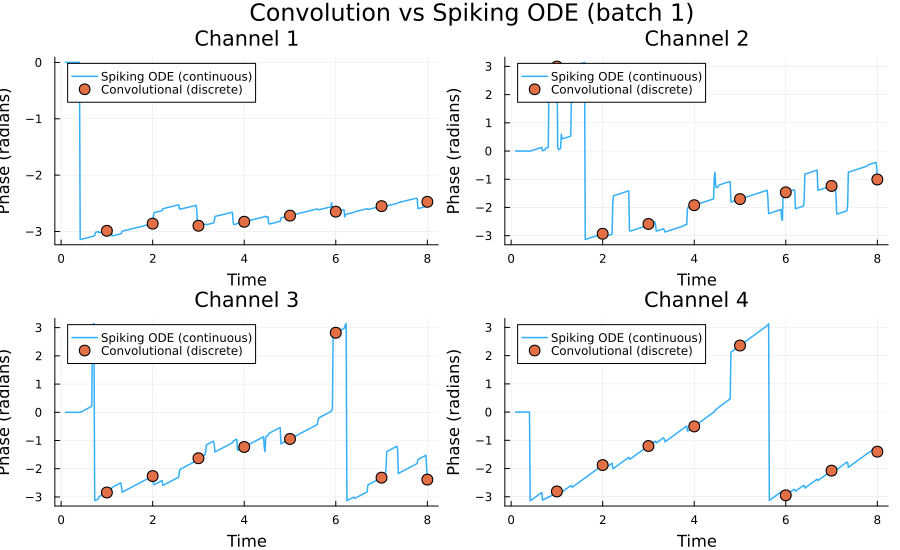

In [20]:
# Densely sample the ODE solution to show continuous trajectory
T = spk_args.t_period
n_dense = 500
dense_times = range(T * 0.1f0, L * T; length=n_dense)
dense_complexes = [sol_ode(t) for t in dense_times]

# Stack into (C_out, n_dense, B) and convert to phases
dense_Z = cat([reshape(s, size(s, 1), 1, size(s, 2)) for s in dense_complexes]...; dims=2)
dense_Y = normalize_to_unit_circle(dense_Z)
dense_phases = Float32.(pi .* complex_to_angle(dense_Y))

# Convolutional sample times (period boundaries)
conv_times = Float32.(T .* (1:L))

b_show = 1
n_show = min(C_out, 4)

plots_cmp = []
for ch in 1:n_show
    p = plot(collect(dense_times), dense_phases[ch, :, b_show],
             label="Spiking ODE (continuous)", lw=1.5, alpha=0.8)
    scatter!(p, conv_times, Float32.(pi .* phases_dirac[ch, :, b_show]),
             label="Convolutional (discrete)", ms=6, marker=:circle)
    plot!(p, title="Channel $ch", xlabel="Time", ylabel="Phase (radians)",
          legend=:topleft)
    push!(plots_cmp, p)
end

fig = plot(plots_cmp...; layout=(2, 2), size=(900, 550),
     plot_title="Convolution vs Spiking ODE (batch $b_show)")

In [21]:
png(fig, "../conv_vs_ode.png")

"../conv_vs_ode.png"

## 6. Dirac Encoding Visualization

The Dirac encoding $e^{k_c \cdot \delta t}$ converts a spike at phase $\theta$
into a per-channel complex response. Each output channel responds differently
because each integrates the impulse at its own eigenvalue $k_c$.

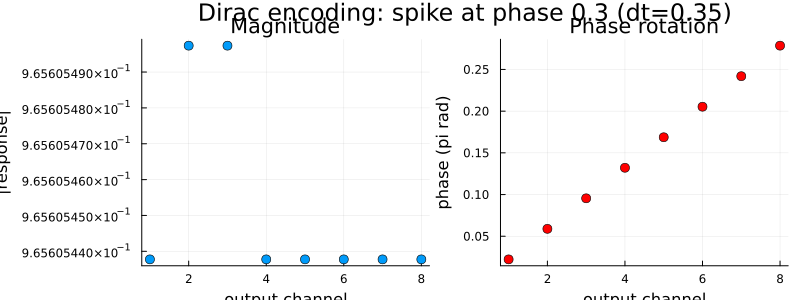

In [8]:
# Visualize the Dirac encoding for a single input phase across channels
theta_ex = 0.3f0
dt_ex = 1f0 * (0.5f0 - theta_ex / 2f0)
responses = exp.(k_c .* dt_ex)

p_enc = plot(layout=(1, 2), size=(800, 300),
             plot_title="Dirac encoding: spike at phase $theta_ex (dt=$(round(dt_ex; digits=2)))")
scatter!(p_enc[1], 1:C_out, abs.(responses),
         xlabel="output channel", ylabel="|response|",
         title="Magnitude", label=nothing, ms=5)
scatter!(p_enc[2], 1:C_out, angle.(responses) ./ pi,
         xlabel="output channel", ylabel="phase (pi rad)",
         title="Phase rotation", label=nothing, ms=5, color=:red)

## Summary

The Phasor SSM provides three equivalent computational views:

- **Toeplitz vs FFT**: Identical to floating-point precision ($< 10^{-5}$).
  The FFT path is $O(L \log L)$ vs $O(L^2)$ for Toeplitz.

- **Recurrence vs Convolution**: Algebraically identical --- unrolling the
  recurrence $U_c[n+1] = \bar{A}_c \cdot U_c[n] + H_c[n]$ produces the
  convolution sum $U = K * H$.

- **Dirac discretization**: The encoding
  $H_c[n] = \sum_j W_{cj} \cdot e^{k_c \cdot \delta t_j[n]}$ is the
  **exact** analytical solution for spike/phase inputs. No temporal
  substeps or surrogate gradients are needed. The encoding is
  per-output-channel (each oscillator responds to the same spike differently),
  which is the key distinction from ZOH discretization.

The Dirac kernel $K_c[n] = e^{k_c \cdot n \cdot T}$ (a pure complex exponential
with no ZOH gain factor) combined with the per-channel Dirac encoding provides
a closed-form, parallelizable computation that exactly reproduces the continuous
R\&F neuron response to spike inputs.